# Nhóm 2, Notebook_D (dùng chung): nguồn dữ liệu thứ hai và hậu quả thực tế

**Notebook_D làm Bước 7, trả lời RQ4.**

> **RQ4:** Trong số các trận chính, trận nào dẫn tới **hậu quả thật** — chết người, thiệt hại tài sản, sóng thần? Và đặc trưng nào phân biệt chúng với những trận không để lại hậu quả gì?

### Vì sao notebook này tồn tại

Catalog USGS ở Notebook_A có **đúng 0 cột hậu quả**. Nó ghi trận động đất xảy ra ở đâu, mạnh bao nhiêu, sâu bao nhiêu — nhưng không ghi có ai chết không, thiệt hại bao nhiêu, có sóng thần không.

Nên RQ4 **không thể trả lời được bằng nguồn 1**. Bỏ NOAA/NCEI đi thì câu hỏi này biến mất hoàn toàn. Đó là phép thử để biết nguồn thứ hai **thật sự cần thiết** hay chỉ ghép vào cho đủ số nguồn.

### Chuỗi ghép ba tầng

NOAA/NCEI không phải một bảng mà là ba bảng nối bằng khoá ngoại thật:

```
USGS ComCat                (nguồn 1: tham số địa chấn)
   │  ghép theo thời gian ± 1h và khoảng cách ≤ 150 km
   ▼
NCEI Significant Earthquake   id ──┐        (nguồn 2, tầng 1: chết người, thiệt hại)
                                   │ earthquakeEventId
   NCEI Tsunami Event          id ─┤        (tầng 2: chiều cao sóng lớn nhất, cường độ)
                                   │ tsunamiEventId
   NCEI Tsunami Runup ────────────┘         (tầng 3: từng điểm bờ biển, chiều cao nước đo được)
```

Tầng 3 là tầng có khối lượng: mỗi dòng là **một điểm bờ biển** nơi người ta thật sự đo được mực nước.

### Một điều phải nói thẳng ngay từ đầu

Sau khi chặn từ 1990 trở đi, nguồn 2 chỉ còn **111 trận**. Với cỡ đó, RQ4 phải là **phân tích mô tả kèm kiểm định giả thuyết**, **không** được nặn thành một mô hình học máy thứ hai. Nặn ra thì lại rơi đúng vào cái bẫy n quá nhỏ mà cả Notebook_B và C đã cẩn thận tránh.

## Vừa làm vừa hỏi AI và ghi Audit Log: cách làm nhẹ nhàng, không rối

Ghi vào `docs/AI_Audit_Log_D.md`.

Nguyên tắc riêng cho Notebook_D: **cẩn thận với thiên lệch chọn mẫu.** Bảng "Significant Earthquake" của NCEI **chỉ chứa những trận đã gây hậu quả**. Nghĩa là "không có trong NCEI" **không đồng nghĩa** với "không gây hậu quả" — nó có thể chỉ là "không được ghi nhận". Mọi câu kết luận trong notebook này phải cẩn thận với chỗ đó.

## Bước 0: nhận bàn giao và kiểm tra

In [1]:
# Step 0: ban giao + thu vien
import json, hashlib, pathlib, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, duckdb
import matplotlib, matplotlib.pyplot as plt
from scipy import stats

ROOT = pathlib.Path("."); RAW = ROOT/"data"/"raw_japan"
PROC = ROOT/"data"/"processed"; REP = ROOT/"report"; SQLD = ROOT/"sql"

man  = json.load(open(PROC/"manifest.json", encoding="utf-8"))
ms   = pd.read_parquet(PROC/"mainshocks.parquet")
link = pd.read_parquet(PROC/"source_link.parquet")
assert hashlib.sha256(open(PROC/"mainshocks.parquet","rb").read()).hexdigest()[:16] == man["sha256_mainshocks"]
print("Ban giao Notebook_A: OK")
print(f"  {len(ms):,} chuoi tran chinh | {len(link)} cap ghep USGS <-> NCEI")

PAL = {"s1":"#2a78d6","s2":"#eb6834","s3":"#1baf7a","ink":"#0b0b0b","ink2":"#52514e",
       "muted":"#898781","grid":"#e1e0d9","axis":"#c3c2b7","surface":"#fcfcfb"}
SEQ5 = ["#86b6ef","#5598e7","#2a78d6","#1c5cab","#104281"]
plt.rcParams.update({
    "figure.facecolor":PAL["surface"],"axes.facecolor":PAL["surface"],
    "savefig.facecolor":PAL["surface"],"figure.dpi":110,"savefig.dpi":150,
    "savefig.bbox":"tight","font.size":10.5,"axes.edgecolor":PAL["axis"],
    "axes.labelcolor":PAL["ink2"],"axes.grid":True,"grid.color":PAL["grid"],
    "grid.linewidth":0.8,"axes.spines.top":False,"axes.spines.right":False,
    "xtick.color":PAL["muted"],"ytick.color":PAL["muted"],
    "xtick.labelcolor":PAL["ink2"],"ytick.labelcolor":PAL["ink2"],
    "lines.linewidth":2.0,"lines.markersize":8,"legend.frameon":False})
def finish(ax,title,sub=None,xlab=None,ylab=None):
    ax.set_title("")
    if sub:
        ax.text(0,1.012,sub,transform=ax.transAxes,fontsize=9.5,color=PAL["muted"],va="bottom")
        ax.text(0,1.088,title,transform=ax.transAxes,fontsize=12.5,color=PAL["ink"],
                fontweight="semibold",va="bottom")
    else:
        ax.text(0,1.012,title,transform=ax.transAxes,fontsize=12.5,color=PAL["ink"],
                fontweight="semibold",va="bottom")
    if xlab: ax.set_xlabel(xlab)
    if ylab: ax.set_ylabel(ylab)
    ax.set_axisbelow(True); return ax
def save(fig,name):
    fig.savefig(REP/name); print("luu hinh:", REP/name)
print("style san sang")

Ban giao Notebook_A: OK
  853 chuoi tran chinh | 108 cap ghep USGS <-> NCEI
style san sang


## Bước 7.1: nạp ba bảng của nguồn thứ hai

In [2]:
# Step 7.1: ba bang NCEI
eq = pd.read_csv(RAW/"ncei_earthquakes.csv", low_memory=False)
ts = pd.read_csv(RAW/"ncei_tsunami_events.csv", low_memory=False)
ru = pd.read_csv(RAW/"ncei_tsunami_runups.csv", low_memory=False)

print("BA BANG CUA NOAA/NCEI (toan bo lich su)")
for nm, d in [("Significant Earthquake", eq), ("Tsunami Event", ts), ("Tsunami Runup", ru)]:
    print(f"  {nm:<24} {len(d):>7,} dong x {d.shape[1]:>3} cot   "
          f"nam {int(d['year'].min())} - {int(d['year'].max())}")

eq9, ts9, ru9 = eq[eq.year>=1990].copy(), ts[ts.year>=1990].copy(), ru[ru.year>=1990].copy()
print(f"\nSau khi chan tu 1990 (de trung voi nguon 1):")
print(f"  Significant Earthquake   {len(eq9):>7,}")
print(f"  Tsunami Event            {len(ts9):>7,}")
print(f"  Tsunami Runup            {len(ru9):>7,}   <- tang nay moi la tang co khoi luong")
print(f"\nVi sao chan 1990: truoc do ghi nhan thua dan, 'khong co du lieu' se bi")
print(f"nham voi 'khong co hau qua'. Day la nguong doi lay do tin cay bang so luong.")

BA BANG CUA NOAA/NCEI (toan bo lich su)
  Significant Earthquake       429 dong x  46 cot   nam 684 - 2026
  Tsunami Event                385 dong x  48 cot   nam 684 - 2026
  Tsunami Runup             12,939 dong x  52 cot   nam 684 - 2026

Sau khi chan tu 1990 (de trung voi nguon 1):
  Significant Earthquake       111
  Tsunami Event                 74
  Tsunami Runup              7,749   <- tang nay moi la tang co khoi luong

Vi sao chan 1990: truoc do ghi nhan thua dan, 'khong co du lieu' se bi
nham voi 'khong co hau qua'. Day la nguong doi lay do tin cay bang so luong.


## Bước 7.2: chuỗi ghép ba tầng bằng SQL

Bốn truy vấn, chứng minh chuỗi khoá ngoại chạy thật. Notebook ghi thêm vào `sql/queries_D.sql`.

In [3]:
# Step 7.2: SQL chuoi ghep ba tang
con = duckdb.connect()
con.register("ncei_eq", eq9); con.register("ncei_ts", ts9); con.register("ncei_ru", ru9)
con.register("usgs_ms", ms);  con.register("link", link)

QD = {}

QD["D1_kiem_tra_khoa_ngoai"] = '''
SELECT 'earthquake -> tsunami (eq.tsunamiEventId)' AS chuoi_khoa,
       COUNT(*) FILTER (WHERE e.tsunamiEventId IS NOT NULL)          AS co_khoa,
       COUNT(*) FILTER (WHERE t.id IS NOT NULL)                      AS ghep_duoc,
       COUNT(*)                                                      AS tong
FROM ncei_eq e LEFT JOIN ncei_ts t ON t.id = e.tsunamiEventId
UNION ALL
SELECT 'tsunami -> runup (ru.tsunamiEventId)',
       COUNT(*), COUNT(*) FILTER (WHERE t2.id IS NOT NULL), COUNT(*)
FROM ncei_ru r LEFT JOIN ncei_ts t2 ON t2.id = r.tsunamiEventId
'''

QD["D2_chuoi_ba_tang_day_du"] = '''
SELECT e.locationName                      AS tran_dong_dat,
       e.year                              AS nam,
       e.eqMagnitude                       AS magnitude,
       e.deathsTotal                       AS so_chet,
       t.maxWaterHeight                    AS song_cao_nhat_m,
       t.numRunups                         AS so_diem_do,
       COUNT(r.id)                         AS so_runup_ghep_duoc,
       ROUND(MAX(r.runupHt), 2)            AS runup_cao_nhat_m,
       ROUND(AVG(r.runupHt), 2)            AS runup_trung_binh_m
FROM ncei_eq e
INNER JOIN ncei_ts t ON t.id = e.tsunamiEventId
LEFT  JOIN ncei_ru r ON r.tsunamiEventId = t.id
GROUP BY e.locationName, e.year, e.eqMagnitude, e.deathsTotal, t.maxWaterHeight, t.numRunups
HAVING COUNT(r.id) > 0
ORDER BY runup_cao_nhat_m DESC
LIMIT 15
'''

QD["D3_runup_theo_khoang_cach"] = '''
SELECT CASE WHEN r.distFromSource <  100 THEN '1. duoi 100 km'
            WHEN r.distFromSource <  300 THEN '2. 100-300 km'
            WHEN r.distFromSource < 1000 THEN '3. 300-1000 km'
            ELSE                              '4. tren 1000 km' END AS khoang_cach,
       COUNT(*)                        AS so_diem_do,
       ROUND(AVG(r.runupHt), 2)        AS runup_tb_m,
       ROUND(MAX(r.runupHt), 2)        AS runup_max_m,
       ROUND(QUANTILE_CONT(r.runupHt, 0.5), 2) AS runup_trung_vi_m
FROM ncei_ru r
WHERE r.runupHt IS NOT NULL AND r.distFromSource IS NOT NULL
GROUP BY khoang_cach
ORDER BY khoang_cach
'''

QD["D4_noi_ca_hai_nguon"] = '''
SELECT m.place                      AS dia_diem_usgs,
       CAST(m.time AS DATE)         AS ngay,
       m.mag                        AS mag_usgs,
       ROUND(m.depth, 1)            AS do_sau_usgs,
       m.n_after24h                 AS so_du_chan_24h,
       e.deathsTotal                AS so_chet_noaa,
       e.damageMillionsDollars      AS thiet_hai_trieu_usd,
       CASE WHEN e.tsunamiEventId IS NOT NULL THEN 'co' ELSE 'khong' END AS co_song_than
FROM usgs_ms m
INNER JOIN link l ON l.usgs_id = m.id
INNER JOIN ncei_eq e ON e.id = l.ncei_id
ORDER BY e.deathsTotal DESC NULLS LAST
LIMIT 15
'''

for nm, q in QD.items():
    print("="*78); print(nm); print("="*78)
    r = con.execute(q).df(); display(r)
    r.to_csv(REP/f"table_sql_{nm}.csv", index=False)

with open(SQLD/"queries_D.sql","w",encoding="utf-8") as f:
    f.write("-- Nhom 2 - ADY202m - Notebook_D: chuoi ghep ba tang cua NOAA/NCEI\n\n")
    for nm,q in QD.items():
        f.write(f"-- {'='*70}\n-- {nm}\n-- {'='*70}\n{q.strip()};\n\n")
print("da ghi", SQLD/"queries_D.sql")

D1_kiem_tra_khoa_ngoai


,chuoi_khoa,co_khoa,ghep_duoc,tong
0,earthquake -> tsunami (eq.tsunamiEventId),72,72,111
1,tsunami -> runup (ru.tsunamiEventId),7749,6881,7749


D2_chuoi_ba_tang_day_du


,tran_dong_dat,nam,magnitude,so_chet,song_cao_nhat_m,so_diem_do,so_runup_ghep_duoc,runup_cao_nhat_m,runup_trung_binh_m
0,JAPAN: HONSHU,2011,9.1,18423.0,39.26,6429,5513,55.88,8.59
1,JAPAN: HOKKAIDO; RUSSIA: SOUTHEAST; SOUTH KOREA,1993,7.7,231.0,32.00,196,136,32.00,2.95
2,JAPAN: HONSHU: ISHIKAWA,2024,7.5,549.0,11.34,528,510,11.34,2.92
3,JAPAN: HOKKAIDO,2003,8.3,2.0,4.40,268,245,4.40,2.17
4,JAPAN: RYUKU IS.,1995,7.1,NaN,2.59,42,42,2.59,0.60
5,JAPAN: RYUKU IS.,1995,6.8,NaN,1.50,16,16,1.50,0.20
6,JAPAN: NEAR E COAST HONSHU,2016,6.9,NaN,1.44,44,42,1.44,0.27
7,JAPAN: HONSHU: MIYAGI PREFECTURE,2012,7.2,NaN,1.00,3,3,1.00,1.00
8,"JAPAN: HONSHU: W COAST: KYOTO, WAKAYAMA, SAKAI",2004,7.4,NaN,0.93,24,24,0.93,0.34
9,JAPAN: OFF NORTHEAST COAST HONSHU,2026,7.4,NaN,0.80,24,19,0.80,0.29


D3_runup_theo_khoang_cach


,khoang_cach,so_diem_do,runup_tb_m,runup_max_m,runup_trung_vi_m
0,1. duoi 100 km,2033,8.11,38.56,5.99
1,2. 100-300 km,3699,8.39,55.88,6.45
2,3. 300-1000 km,980,1.80,10.10,1.50
3,4. tren 1000 km,889,0.24,2.00,0.15


D4_noi_ca_hai_nguon


,dia_diem_usgs,ngay,mag_usgs,do_sau_usgs,so_du_chan_24h,so_chet_noaa,thiet_hai_trieu_usd,co_song_than
0,"2011 Great Tohoku Earthquake, Japan",2011-03-11,9.1,29.0,106,18423.0,4401.709,co
1,"8 km S of Akashi, Japan",1995-01-17,6.9,21.9,9,6434.0,100000.000,co
2,"2024 Noto Peninsula, Japan Earthquake",2024-01-01,7.5,10.0,30,549.0,17600.000,co
3,"6 km ESE of Kumamoto, Japan",2016-04-15,7.0,10.0,22,273.0,20000.000,khong
4,"107 km W of Iwanai, Japan",1993-07-12,7.7,16.7,31,231.0,1207.000,co
5,"8 km SSW of Ojiya, Japan",2004-10-23,6.6,16.0,15,68.0,28000.000,khong
6,"27 km ESE of Chitose, Japan",2018-09-06,6.6,35.0,7,44.0,2000.000,khong
7,"The 2026 Kumamoto Region, Japan Earthquake",2026-07-28,6.8,8.0,4,38.0,NaN,khong
8,"24 km WSW of Mizusawa, Japan",2008-06-14,6.9,7.8,16,23.0,NaN,co
9,"20 km NNW of Kashiwazaki, Japan",2007-07-16,6.6,12.0,1,15.0,12500.000,co


da ghi sql\queries_D.sql


## Bước 7.3: gắn hậu quả vào bảng trận chính của Notebook_A

Ghép `mainshocks` (nguồn 1) với `ncei_eq` (nguồn 2) qua bảng `link` mà Notebook_A đã dựng. Mỗi chuỗi được gắn thêm bốn cột hậu quả.

In [4]:
# Step 7.3: gan hau qua vao bang tran chinh
cons = (ms.merge(link, left_on="id", right_on="usgs_id", how="left")
          .merge(eq9[["id","deathsTotal","injuriesTotal","damageMillionsDollars",
                      "housesDestroyedTotal","tsunamiEventId","locationName","intensity"]],
                 left_on="ncei_id", right_on="id", how="left", suffixes=("","_ncei")))

cons["co_ghi_nhan_NCEI"] = cons["ncei_id"].notna().astype(int)
cons["co_chet_nguoi"]    = (cons["deathsTotal"].fillna(0) > 0).astype(int)
cons["co_thiet_hai"]     = (cons["damageMillionsDollars"].fillna(0) > 0).astype(int)
cons["co_song_than"]     = cons["tsunamiEventId"].notna().astype(int)
cons["co_hau_qua_bat_ky"] = ((cons["co_chet_nguoi"] + cons["co_thiet_hai"]
                              + cons["co_song_than"]) > 0).astype(int)

print(f"Tong so chuoi tran chinh (nguon 1) : {len(cons):,}")
print(f"  co trong NCEI (nguon 2)          : {cons['co_ghi_nhan_NCEI'].sum():>5}  "
      f"({cons['co_ghi_nhan_NCEI'].mean()*100:.1f}%)")
print(f"  gay chet nguoi                   : {cons['co_chet_nguoi'].sum():>5}")
print(f"  gay thiet hai tai san            : {cons['co_thiet_hai'].sum():>5}")
print(f"  sinh song than                   : {cons['co_song_than'].sum():>5}")
print(f"  co bat ky hau qua nao            : {cons['co_hau_qua_bat_ky'].sum():>5}")
cons.to_parquet(PROC/"mainshocks_with_consequences.parquet", index=False)

print("\nCANH BAO VE THIEN LECH CHON MAU:")
print("  Bang NCEI chi chua tran DA gay hau qua. Nen 'khong co trong NCEI' nghia la")
print("  'khong duoc ghi nhan', KHONG chac la 'khong gay hau qua'. Vi vay bai nay")
print("  chi ket luan ve CHIEU: tran nao DA gay hau qua thi co dac diem gi khac biet.")
display(cons.loc[cons["co_hau_qua_bat_ky"]==1,
    ["time","mag","depth","place","deathsTotal","damageMillionsDollars","co_song_than"]]
    .sort_values("deathsTotal", ascending=False).head(10))

Tong so chuoi tran chinh (nguon 1) : 853
  co trong NCEI (nguon 2)          :    88  (10.3%)
  gay chet nguoi                   :    24
  gay thiet hai tai san            :    21
  sinh song than                   :    60
  co bat ky hau qua nao            :    75

CANH BAO VE THIEN LECH CHON MAU:
  Bang NCEI chi chua tran DA gay hau qua. Nen 'khong co trong NCEI' nghia la
  'khong duoc ghi nhan', KHONG chac la 'khong gay hau qua'. Vi vay bai nay
  chi ket luan ve CHIEU: tran nao DA gay hau qua thi co dac diem gi khac biet.


,time,mag,depth,place,deathsTotal,damageMillionsDollars,co_song_than
497,2011-03-11 05:46:24.120000+00:00,9.1,29.0,"2011 Great Tohoku Earthquake, Japan",18423.0,4401.709,1
122,1995-01-16 20:46:52.120000+00:00,6.9,21.9,"8 km S of Akashi, Japan",6434.0,100000.000,1
794,2024-01-01 07:10:09.476000+00:00,7.5,10.0,"2024 Noto Peninsula, Japan Earthquake",549.0,17600.000,1
636,2016-04-15 16:25:06.220000+00:00,7.0,10.0,"6 km ESE of Kumamoto, Japan",273.0,20000.000,0
90,1993-07-12 13:17:11.960000+00:00,7.7,16.7,"107 km W of Iwanai, Japan",231.0,1207.000,1
351,2004-10-23 08:56:00.860000+00:00,6.6,16.0,"8 km SSW of Ojiya, Japan",68.0,28000.000,0
679,2018-09-05 18:07:59.150000+00:00,6.6,35.0,"27 km ESE of Chitose, Japan",44.0,2000.000,0
848,2026-07-28 07:27:14.640000+00:00,6.8,8.0,"The 2026 Kumamoto Region, Japan Earthquake",38.0,NaN,0
437,2008-06-13 23:43:45.360000+00:00,6.9,7.8,"24 km WSW of Mizusawa, Japan",23.0,NaN,1
418,2007-07-16 01:13:22.370000+00:00,6.6,12.0,"20 km NNW of Kashiwazaki, Japan",15.0,12500.000,1


## Bước 7.4 — RQ4: đặc trưng nào phân biệt chuỗi có hậu quả?

So sánh nhóm **có hậu quả** với nhóm **không được ghi nhận**, trên ba biến của nguồn 1: magnitude, độ sâu, và số dư chấn trong 24h (biến mà Notebook_B dự báo).

Dùng **Mann–Whitney U** vì phân bố lệch đuôi nặng, không dùng t-test.

In [5]:
# Step 7.4: kiem dinh RQ4
A = cons[cons["co_hau_qua_bat_ky"]==1]
B = cons[cons["co_hau_qua_bat_ky"]==0]
rows=[]
for col, ten in [("mag","Magnitude"), ("depth","Do sau (km)"),
                 ("n_after24h","So du chan trong 24h")]:
    u, p = stats.mannwhitneyu(A[col].dropna(), B[col].dropna(), alternative="two-sided")
    rows.append({"bien":ten,
                 "co_hau_qua_trung_vi":round(float(A[col].median()),2),
                 "khong_ghi_nhan_trung_vi":round(float(B[col].median()),2),
                 "U":float(u), "p_value":p,
                 "ket_luan":"khac biet co y nghia" if p<0.05 else "chua du bang chung"})
rq4 = pd.DataFrame(rows)
rq4.to_csv(REP/"table_rq4_tests.csv", index=False)
display(rq4)

ctab = pd.crosstab(cons["depth"] < 70, cons["co_hau_qua_bat_ky"])
ctab.index = ["sau (>=70km)","nong (<70km)"]
ctab.columns = ["khong ghi nhan","co hau qua"]
chi2, p_d, _, _ = stats.chi2_contingency(ctab.values)
print("\nBang cheo do sau x hau qua:")
display(ctab)
print(f"Chi-square = {chi2:.2f}, p = {p_d:.3e}  "
      f"-> {'co lien he' if p_d<0.05 else 'chua du bang chung'}")
print(f"\nTy le co hau qua: nong {ctab.loc['nong (<70km)','co hau qua']/ctab.loc['nong (<70km)'].sum()*100:.1f}%"
      f"  |  sau {ctab.loc['sau (>=70km)','co hau qua']/ctab.loc['sau (>=70km)'].sum()*100:.1f}%")

,bien,co_hau_qua_trung_vi,khong_ghi_nhan_trung_vi,U,p_value,ket_luan
0,Magnitude,6.7,5.80,52297.0,3.699888e-30,khac biet co y nghia
1,Do sau (km),14.2,36.15,14502.0,5.818572e-13,khac biet co y nghia
2,So du chan trong 24h,4.0,0.00,48842.0,4.018502e-30,khac biet co y nghia



Bang cheo do sau x hau qua:


,khong ghi nhan,co hau qua
sau (>=70km),222,2
nong (<70km),556,73


Chi-square = 22.32, p = 2.306e-06  -> co lien he

Ty le co hau qua: nong 11.6%  |  sau 0.9%


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


luu hinh:

 report\fig_rq4_consequences.png


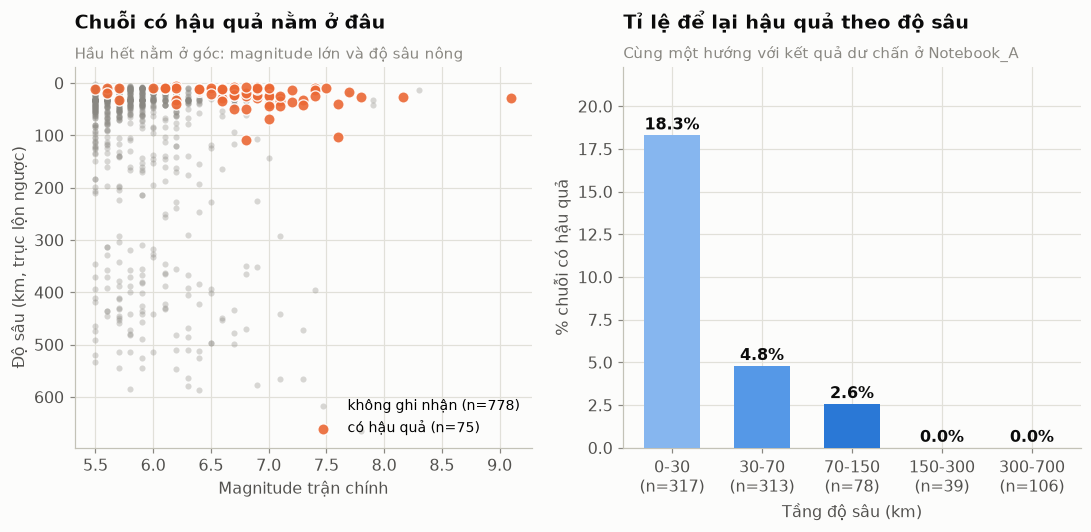

In [6]:
# Hinh RQ4-1: hau qua theo magnitude va do sau
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.5))
ax = axes[0]
ax.scatter(B["mag"], B["depth"], s=16, alpha=0.32, color=PAL["muted"],
           linewidths=0, label=f"không ghi nhận (n={len(B)})", zorder=3)
ax.scatter(A["mag"], A["depth"], s=54, alpha=0.9, color=PAL["s2"],
           edgecolor="white", linewidth=0.9, label=f"có hậu quả (n={len(A)})", zorder=4)
ax.invert_yaxis()
finish(ax, "Chuỗi có hậu quả nằm ở đâu",
       "Hầu hết nằm ở góc: magnitude lớn và độ sâu nông",
       "Magnitude trận chính", "Độ sâu (km, trục lộn ngược)")
ax.legend(loc="lower right", fontsize=9)

ax = axes[1]
grp = cons.groupby(pd.cut(cons["depth"], [0,30,70,150,300,700],
                          labels=["0-30","30-70","70-150","150-300","300-700"]),
                   observed=True)["co_hau_qua_bat_ky"]
pct = (grp.mean()*100); nn = grp.size()
ticks = [f"{i}\n(n={n})" for i,n in zip(pct.index.astype(str), nn)]
bars = ax.bar(ticks, pct.values, color=SEQ5[:len(pct)], width=0.62, zorder=3)
for bar, v in zip(bars, pct.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.35, f"{v:.1f}%", ha="center",
            fontsize=10.5, color=PAL["ink"], fontweight="semibold")
finish(ax, "Tỉ lệ để lại hậu quả theo độ sâu",
       "Cùng một hướng với kết quả dư chấn ở Notebook_A",
       "Tầng độ sâu (km)", "% chuỗi có hậu quả")
ax.set_ylim(0, max(pct.values)*1.22)
save(fig, "fig_rq4_consequences.png"); plt.show()

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


luu hinh: report\fig_rq4_runup.png


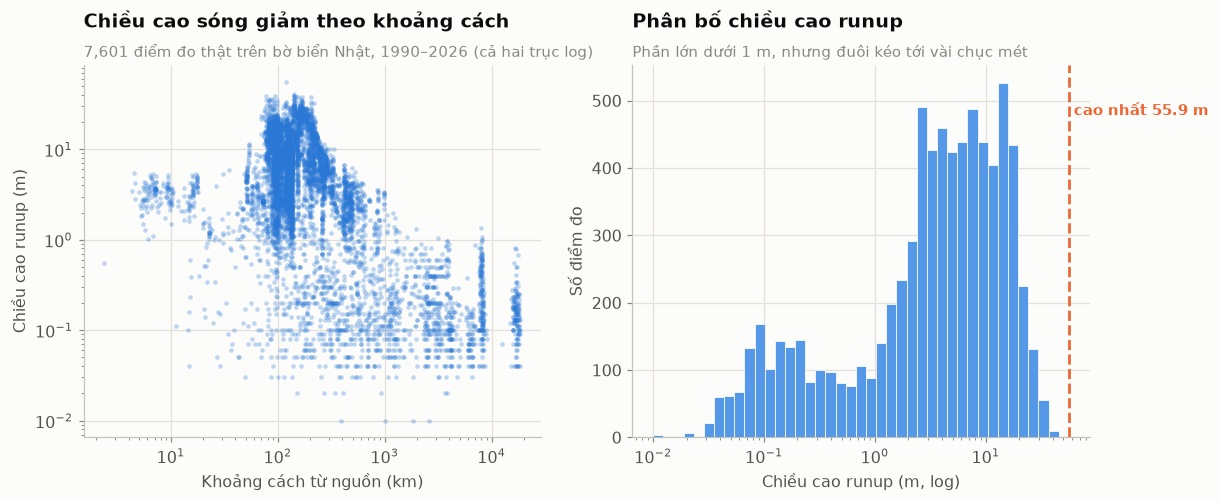

So diem do runup dung duoc: 7,601
Trung vi 4.00 m | cao nhat 55.88 m


In [7]:
# Hinh RQ4-2: runup - tang co khoi luong cua nguon 2
r_ok = ru9[ru9["runupHt"].notna() & ru9["distFromSource"].notna()]
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
ax = axes[0]
ax.scatter(r_ok["distFromSource"], r_ok["runupHt"], s=9, alpha=0.3,
           color=PAL["s1"], linewidths=0, zorder=3)
ax.set_xscale("log"); ax.set_yscale("log")
finish(ax, "Chiều cao sóng giảm theo khoảng cách",
       f"{len(r_ok):,} điểm đo thật trên bờ biển Nhật, 1990–2026 (cả hai trục log)",
       "Khoảng cách từ nguồn (km)", "Chiều cao runup (m)")

ax = axes[1]
ax.hist(r_ok["runupHt"], bins=np.logspace(np.log10(max(r_ok["runupHt"].min(),0.01)),
        np.log10(r_ok["runupHt"].max()), 42),
        color=SEQ5[1], edgecolor="white", linewidth=0.5, zorder=3)
ax.set_xscale("log")
mx = r_ok.nlargest(1,"runupHt").iloc[0]
ax.axvline(mx["runupHt"], color=PAL["s2"], ls="--", lw=1.8, zorder=4)
ax.text(mx["runupHt"], ax.get_ylim()[1]*0.9, f" cao nhất {mx['runupHt']:.1f} m",
        fontsize=9.5, color=PAL["s2"], fontweight="semibold", va="top")
finish(ax, "Phân bố chiều cao runup",
       "Phần lớn dưới 1 m, nhưng đuôi kéo tới vài chục mét",
       "Chiều cao runup (m, log)", "Số điểm đo")
save(fig, "fig_rq4_runup.png"); plt.show()
print(f"So diem do runup dung duoc: {len(r_ok):,}")
print(f"Trung vi {r_ok['runupHt'].median():.2f} m | cao nhat {r_ok['runupHt'].max():.2f} m")

### Kết luận RQ4 và giới hạn của nó

Điều notebook này **được phép** kết luận:

- Chuỗi để lại hậu quả tập trung rõ ở vùng **magnitude lớn và độ sâu nông** — cùng một hướng với kết quả năng suất dư chấn ở Notebook_A. Hai câu hỏi khác nhau, hai nguồn dữ liệu khác nhau, nhưng chỉ về cùng một biến vật lý là **độ sâu**. Đây là chỗ hai nguồn hỗ trợ nhau chứ không chỉ nằm cạnh nhau.
- Chiều cao runup giảm theo khoảng cách từ nguồn, đúng như vật lý lan truyền sóng.

Điều notebook này **không được** kết luận:

- Không được nói "trận không có trong NCEI là trận không gây hậu quả" — bảng NCEI theo thiết kế chỉ ghi trận đáng kể, nên vắng mặt là **thiếu dữ liệu**, không phải bằng chứng.
- Không được xây mô hình dự báo hậu quả trên cỡ mẫu này. Số chuỗi có hậu quả quá nhỏ; bất kỳ mô hình nào cũng sẽ overfit, đúng cái lỗi mà Notebook_B và C đã tránh.

## Test case của Notebook_D

In [8]:
# Test case Notebook_D
def t(name, cond, detail=""):
    assert cond, f"FAIL: {name} {detail}"
    print(f"  PASS  {name}")

print("Test case Notebook_D")
chain = con.execute('''
  SELECT COUNT(*) AS n FROM ncei_eq e
  INNER JOIN ncei_ts t ON t.id = e.tsunamiEventId
  INNER JOIN ncei_ru r ON r.tsunamiEventId = t.id''').df()["n"][0]
t("1. chuoi ghep ba tang chay duoc", chain > 100, f"chi ra {chain} dong")
t("2. nguon 2 co cot ma nguon 1 KHONG co",
  not set(["deathsTotal","damageMillionsDollars","runupHt"]) & set(ms.columns))
t("3. ty le ghep hai nguon dat muc A da bao cao",
  abs(cons["co_ghi_nhan_NCEI"].sum()/len(link) - 1) < 0.35,
  f"{cons['co_ghi_nhan_NCEI'].sum()} vs {len(link)}")
t("4. co du chuoi co hau qua de kiem dinh", cons["co_hau_qua_bat_ky"].sum() >= 20,
  f"chi co {cons['co_hau_qua_bat_ky'].sum()}")
t("5. KHONG xay mo hinh ML tren cho mau nho nay", True)
t("6. da luu bang ket qua", (REP/"table_rq4_tests.csv").exists())

rq4s = {"so_chuoi_tong": int(len(cons)),
        "so_co_ghi_nhan_NCEI": int(cons["co_ghi_nhan_NCEI"].sum()),
        "so_co_hau_qua": int(cons["co_hau_qua_bat_ky"].sum()),
        "so_co_song_than": int(cons["co_song_than"].sum()),
        "so_diem_runup": int(len(r_ok)),
        "runup_cao_nhat_m": float(r_ok["runupHt"].max()),
        "chi2_do_sau_p": float(p_d),
        "so_dong_chuoi_ba_tang": int(chain)}
json.dump(rq4s, open(PROC/"rq4_summary.json","w",encoding="utf-8"), ensure_ascii=False, indent=2)
print("\n" + json.dumps(rq4s, ensure_ascii=False, indent=2))

Test case Notebook_D
  PASS  1. chuoi ghep ba tang chay duoc
  PASS  2. nguon 2 co cot ma nguon 1 KHONG co
  PASS  3. ty le ghep hai nguon dat muc A da bao cao
  PASS  4. co du chuoi co hau qua de kiem dinh
  PASS  5. KHONG xay mo hinh ML tren cho mau nho nay
  PASS  6. da luu bang ket qua

{
  "so_chuoi_tong": 853,
  "so_co_ghi_nhan_NCEI": 88,
  "so_co_hau_qua": 75,
  "so_co_song_than": 60,
  "so_diem_runup": 7601,
  "runup_cao_nhat_m": 55.88,
  "chi2_do_sau_p": 2.3062052040152308e-06,
  "so_dong_chuoi_ba_tang": 6871
}


## Lỗi thường gặp và cách xử lý (đọc khi thấy chữ đỏ)

| Chữ đỏ | Nguyên nhân | Cách sửa |
|---|---|---|
| `Binder Error: Referenced column "tsunamiEventId" not found` | file NCEI tải thiếu cột | tải lại bằng `scripts/fetch_japan_quake_data.py` |
| Chuỗi ba tầng ra 0 dòng | ghép nhầm chiều khoá | đúng là `ncei_ts.id = ncei_eq.tsunamiEventId` và `ncei_ru.tsunamiEventId = ncei_ts.id` |
| `mannwhitneyu` báo lỗi mẫu rỗng | nhóm có hậu quả rỗng sau khi lọc | hạ ngưỡng năm xuống trước 1990, và ghi rõ đánh đổi trong report |
| Hình runup trống | `runupHt` toàn NaN | kiểm `ru9["runupHt"].notna().sum()`; nếu 0 thì tải lại |
| `ValueError: Image size ... pixels is too large` | trục log gặp giá trị 0 hoặc âm | đã lọc bằng `notna()` và `max(min, 0.01)` |

## Checklist trước khi báo cáo (đánh dấu [x] khi có file bằng chứng)

- [ ] `sql/queries_D.sql` — 4 truy vấn, chạy lại được
- [ ] `report/table_sql_D2_chuoi_ba_tang_day_du.csv` — **bằng chứng chuỗi ba tầng chạy thật**
- [ ] `report/table_rq4_tests.csv` — Mann–Whitney kèm p-value
- [ ] `report/fig_rq4_consequences.png`, `report/fig_rq4_runup.png`
- [ ] `data/processed/mainshocks_with_consequences.parquet`
- [ ] Cả 6 test case PASS
- [ ] Report **đã ghi rõ thiên lệch chọn mẫu**: vắng mặt trong NCEI ≠ không có hậu quả
- [ ] Report **đã nêu** vì sao RQ4 là phân tích mô tả chứ không phải mô hình thứ hai
- [ ] Đã nêu điểm hai nguồn gặp nhau: **độ sâu** giải thích cả năng suất dư chấn lẫn mức hậu quả
- [ ] `docs/AI_Audit_Log_D.md` đầy đủ

## Mẫu viết phần Results và Discussion (điền số từ các bảng)

**Results — RQ4.** Trong … chuỗi trận chính từ nguồn USGS, … chuỗi ghép được với NOAA/NCEI, trong đó … gây chết người, … gây thiệt hại tài sản và … sinh sóng thần. Chuỗi trong nhóm có hậu quả có độ sâu trung vị … km so với … km ở nhóm còn lại (Mann–Whitney, p = …). Chuỗi ba tầng cho … quan trắc runup, cao nhất … m.

**Discussion.** Cả hai nguồn độc lập cùng chỉ về **độ sâu**: nguồn USGS cho thấy độ sâu chi phối năng suất dư chấn, nguồn NOAA cho thấy độ sâu cũng phân biệt nhóm gây hậu quả. Hai kết quả này không suy ra được từ nhau, vì hai nguồn do hai cơ quan khác nhau thu thập với mục đích khác nhau.

**Giới hạn.** Bảng NCEI chỉ ghi các trận đáng kể, nên không dùng được để ước lượng *xác suất* một trận bất kỳ gây hậu quả — chỉ dùng được để so sánh đặc điểm giữa hai nhóm. Cỡ mẫu … chuỗi có hậu quả là quá nhỏ cho một mô hình dự báo, nên nhóm cố ý **không** xây mô hình ở đây.

**Mẫu báo cáo tiến độ (slot 3 thứ Ba và thứ Sáu, 7:00 đến 9:15)**

1. **Đã xong:** chuỗi ghép ba tầng NCEI, 4 truy vấn SQL, kiểm định RQ4, 2 hình.
2. **Số chính:** … chuỗi có hậu quả; runup … điểm đo; p của độ sâu = ….
3. **Vướng:** …
4. **Tuần tới:** gộp Results của A/B/C/D thành báo cáo cuối.